# COGS 181 Final Project
## Does Aggressive Data Augmentation Disproportionately Benefit Shallow CNNs on CIFAR-10?

**Author:** Jae Kim  
**Date:** March 2026  
**Course:** COGS 181, UCSD Winter 2026

---
**Experiment design:** 2 architectures × 4 augmentation levels = 8 total runs  
**Fixed:** SGD (momentum=0.9, wd=1e-4), cosine LR annealing (0.1→0), batch_size=128, epochs=50, seed=42

## Setup: Paths
Results are saved to `~/cogs181_results/` (e.g. `C:\Users\you\cogs181_results` on Windows).
This folder persists between runs.

In [1]:
import os

# DataHub: home directory is persistent across sessions
RESULTS_DIR = os.path.expanduser('~/cogs181_results')
FIGURES_DIR = f'{RESULTS_DIR}/figures'
LOGS_CSV    = f'{RESULTS_DIR}/run_logs.csv'

os.makedirs(FIGURES_DIR, exist_ok=True)

print(f'Results dir : {RESULTS_DIR}')
print(f'Logs CSV    : {LOGS_CSV}')
print(f'Figures dir : {FIGURES_DIR}')

Results dir : C:\Users\luluz/cogs181_results
Logs CSV    : C:\Users\luluz/cogs181_results/run_logs.csv
Figures dir : C:\Users\luluz/cogs181_results/figures


## Section 0: Config

In [2]:
CONFIG = {
    # Training
    'epochs':        50,
    'batch_size':    128,
    'num_workers':   0,      # 0 is required for Jupyter on Windows
    'seed':          42,

    # Optimizer (SGD)
    'lr_init':       0.1,
    'lr_min':        0.0,
    'momentum':      0.9,
    'weight_decay':  1e-4,

    # Dataset
    'num_classes':   10,
    'img_size':      32,

    # CIFAR-10 normalization constants
    'mean': (0.4914, 0.4822, 0.4465),
    'std':  (0.2023, 0.1994, 0.2010),

    # Experiment grid
    'architectures': ['ShallowCNN', 'DeepCNN'],
    'aug_levels':    ['none', 'basic', 'medium', 'aggressive'],
}

print('CONFIG loaded:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

CONFIG loaded:
  epochs: 50
  batch_size: 128
  num_workers: 0
  seed: 42
  lr_init: 0.1
  lr_min: 0.0
  momentum: 0.9
  weight_decay: 0.0001
  num_classes: 10
  img_size: 32
  mean: (0.4914, 0.4822, 0.4465)
  std: (0.2023, 0.1994, 0.201)
  architectures: ['ShallowCNN', 'DeepCNN']
  aug_levels: ['none', 'basic', 'medium', 'aggressive']


## Section 1: Data Loading

In [3]:
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, random_split

print(f'PyTorch version : {torch.__version__}')
print(f'Torchvision     : {torchvision.__version__}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device          : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU detected. Check that your PyTorch install has CUDA support.')
    print('  Run: python -c "import torch; print(torch.cuda.is_available())"')


def get_transforms(aug_level: str, mean, std):
    """Return (train_transform, test_transform) for a given augmentation level."""
    normalize = T.Normalize(mean, std)
    base = [T.ToTensor(), normalize]

    if aug_level == 'none':
        train_tf = T.Compose(base)

    elif aug_level == 'basic':
        train_tf = T.Compose([
            T.RandomHorizontalFlip(),
        ] + base)

    elif aug_level == 'medium':
        train_tf = T.Compose([
            T.RandomHorizontalFlip(),
            T.RandomCrop(32, padding=4),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        ] + base)

    elif aug_level == 'aggressive':
        train_tf = T.Compose([
            T.RandomHorizontalFlip(),
            T.RandomCrop(32, padding=4),
            T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.2),
            T.RandomGrayscale(p=0.1),
            T.ToTensor(),
            T.RandomErasing(p=0.5),
            normalize,
        ])
        # Note: RandomErasing must come after ToTensor (operates on tensors)
        return train_tf, T.Compose(base)

    else:
        raise ValueError(f'Unknown aug_level: {aug_level}')

    test_tf = T.Compose(base)
    return train_tf, test_tf


def get_dataloaders(aug_level: str, batch_size: int, num_workers: int):
    """Return (train_loader, val_loader, test_loader).
    
    - Train split: 45,000 samples with augmentation
    - Val split  : 5,000 samples with NO augmentation (clean evaluation)
    - Test split : 10,000 samples with NO augmentation
    """
    mean, std = CONFIG['mean'], CONFIG['std']
    train_tf, test_tf = get_transforms(aug_level, mean, std)

    full_train = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=train_tf
    )
    full_train_clean = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=False, transform=test_tf
    )

    generator = torch.Generator().manual_seed(CONFIG['seed'])
    train_idx, val_idx = random_split(
        range(len(full_train)), [45000, 5000], generator=generator
    )

    from torch.utils.data import Subset
    train_set = Subset(full_train,       train_idx.indices)
    val_set   = Subset(full_train_clean, val_idx.indices)

    test_set = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=test_tf
    )

    loader_kwargs = dict(batch_size=batch_size, num_workers=num_workers,
                         pin_memory=(DEVICE.type == 'cuda'))

    train_loader = DataLoader(train_set, shuffle=True,  **loader_kwargs)
    val_loader   = DataLoader(val_set,   shuffle=False, **loader_kwargs)
    test_loader  = DataLoader(test_set,  shuffle=False, **loader_kwargs)

    return train_loader, val_loader, test_loader


print('\nDownloading CIFAR-10 (first call only) ...')
_tl, _vl, _tel = get_dataloaders('none', CONFIG['batch_size'], CONFIG['num_workers'])
print(f'Train batches: {len(_tl)} | Val batches: {len(_vl)} | Test batches: {len(_tel)}')
x, y = next(iter(_tl))
print(f'Batch shape  : {x.shape}  |  Label shape: {y.shape}')

PyTorch version : 2.9.0+cu126
Torchvision     : 0.24.0+cu126
Device          : cuda
GPU             : NVIDIA GeForce GTX 1080



100.0%


Train batches: 352 | Val batches: 40 | Test batches: 79
Batch shape  : torch.Size([128, 3, 32, 32])  |  Label shape: torch.Size([128])


## Section 2: Model Definitions

In [4]:
import torch.nn as nn


def _he_init(module):
    """Apply He (Kaiming) initialization to Conv and Linear layers."""
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
        if module.bias is not None:
            nn.init.zeros_(module.bias)


class ShallowCNN(nn.Module):
    """3-block shallow CNN  (~0.4M parameters).
    
    Architecture:
        Conv(3,32,3,p=1)  -> BN -> ReLU -> MaxPool(2)   [32 x 16 x 16]
        Conv(32,64,3,p=1) -> BN -> ReLU -> MaxPool(2)   [64 x  8 x  8]
        Conv(64,128,3,p=1)-> BN -> ReLU -> MaxPool(2)   [128 x 4 x  4]
        Flatten -> Linear(2048, 256) -> ReLU -> Dropout(0.5) -> Linear(256, 10)
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 32 x 16 x 16
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 64 x  8 x  8
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                              # 128 x 4 x  4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
        self.apply(_he_init)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class DeepCNN(nn.Module):
    """6-conv deep CNN  (~3.0M parameters).
    
    Architecture:
        Block1: Conv(3,64,3,p=1)->BN->ReLU -> Conv(64,64,3,p=1)->BN->ReLU -> MaxPool(2)
        Block2: Conv(64,128,3,p=1)->BN->ReLU-> Conv(128,128,3,p=1)->BN->ReLU->MaxPool(2)
        Block3: Conv(128,256,3,p=1)->BN->ReLU->Conv(256,256,3,p=1)->BN->ReLU->MaxPool(2)
        Flatten -> Linear(4096, 512) -> ReLU -> Dropout(0.5) -> Linear(512, 10)
    """

    def __init__(self, num_classes: int = 10):
        super().__init__()

        def conv_bn_relu(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        self.features = nn.Sequential(
            # Block 1
            conv_bn_relu(3,   64),
            conv_bn_relu(64,  64),
            nn.MaxPool2d(2),                              # 64  x 16 x 16
            # Block 2
            conv_bn_relu(64,  128),
            conv_bn_relu(128, 128),
            nn.MaxPool2d(2),                              # 128 x  8 x  8
            # Block 3
            conv_bn_relu(128, 256),
            conv_bn_relu(256, 256),
            nn.MaxPool2d(2),                              # 256 x  4 x  4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
        self.apply(_he_init)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def count_parameters(model: nn.Module) -> int:
    """Return total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_model(arch_name: str) -> nn.Module:
    """Instantiate a model by name and send to DEVICE."""
    if arch_name == 'ShallowCNN':
        model = ShallowCNN(num_classes=CONFIG['num_classes'])
    elif arch_name == 'DeepCNN':
        model = DeepCNN(num_classes=CONFIG['num_classes'])
    else:
        raise ValueError(f'Unknown architecture: {arch_name}')
    return model.to(DEVICE)


# ── Verification ──────────────────────────────────────────────────────────────
print('=== Model verification ===')
dummy = torch.randn(4, 3, 32, 32).to(DEVICE)

for name in ['ShallowCNN', 'DeepCNN']:
    m = build_model(name)
    out = m(dummy)
    params = count_parameters(m)
    print(f'{name:<12}  output: {tuple(out.shape)}   params: {params:,}')
    assert out.shape == (4, 10), f'Expected (4,10), got {out.shape}'

print('\nAll shape checks passed!')

=== Model verification ===
ShallowCNN    output: (4, 10)   params: 620,810
DeepCNN       output: (4, 10)   params: 3,249,994

All shape checks passed!


## Section 3: Training Infrastructure

In [5]:
import time
import csv
import copy
import numpy as np

torch.backends.cudnn.benchmark = True  # faster conv selection on fixed input size


def set_seed(seed: int):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    np.random.seed(seed)


def train_one_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns (avg_loss, accuracy)."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total   += inputs.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns (avg_loss, accuracy)."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(targets).sum().item()
            total   += inputs.size(0)

    return running_loss / total, correct / total


def run_experiment(arch_name: str, aug_level: str, config: dict):
    """Train one (arch, aug_level) combination for config['epochs'] epochs.
    
    Returns:
        history    : list of dicts, one per epoch
        test_acc   : float  (accuracy on the held-out test set)
        elapsed    : float  (wall-clock seconds)
    """
    set_seed(config['seed'])

    train_loader, val_loader, test_loader = get_dataloaders(
        aug_level, config['batch_size'], config['num_workers']
    )

    model     = build_model(arch_name)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=config['lr_init'],
        momentum=config['momentum'],
        weight_decay=config['weight_decay'],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=config['epochs'], eta_min=config['lr_min']
    )

    best_val_acc   = 0.0
    best_weights   = None
    history        = []
    t0             = time.time()

    for epoch in range(1, config['epochs'] + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss,   val_acc   = evaluate(model, val_loader,   criterion, DEVICE)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        row = {
            'arch':       arch_name,
            'aug':        aug_level,
            'epoch':      epoch,
            'train_loss': round(train_loss, 5),
            'train_acc':  round(train_acc,  5),
            'val_loss':   round(val_loss,   5),
            'val_acc':    round(val_acc,    5),
            'lr':         round(optimizer.param_groups[0]['lr'], 6),
        }
        history.append(row)

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{config["epochs"]}  '
                  f'train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  '
                  f'lr={optimizer.param_groups[0]["lr"]:.5f}')

    # Load best checkpoint, evaluate on test set
    model.load_state_dict(best_weights)
    _, test_acc = evaluate(model, test_loader, criterion, DEVICE)

    elapsed = time.time() - t0
    print(f'  --> test_acc={test_acc:.4f}  best_val_acc={best_val_acc:.4f}  '
          f'time={elapsed/60:.1f}m')

    return history, test_acc, elapsed


# ── Quick smoke test (2 epochs) ───────────────────────────────────────────────
print('=== Smoke test: ShallowCNN / none / 2 epochs ===')
smoke_cfg = {**CONFIG, 'epochs': 2}
smoke_hist, smoke_acc, smoke_time = run_experiment('ShallowCNN', 'none', smoke_cfg)

assert smoke_hist[-1]['train_acc'] > 0.10, 'Train acc <= 10% — something is wrong!'
print(f'Smoke test passed! train_acc={smoke_hist[-1]["train_acc"]:.3f}')

=== Smoke test: ShallowCNN / none / 2 epochs ===
  Epoch   1/2  train_acc=0.201  val_acc=0.285  lr=0.05000
  --> test_acc=0.3509  best_val_acc=0.3306  time=0.8m
Smoke test passed! train_acc=0.282


## Section 4: Run All Experiments

8 runs total (2 archs × 4 aug levels). Results are saved to CSV **after every run** so a kernel crash won't lose data.

In [6]:
import pandas as pd

# ── Fieldnames for the CSV ────────────────────────────────────────────────────
LOG_FIELDS = ['arch', 'aug', 'epoch', 'train_loss', 'train_acc',
              'val_loss', 'val_acc', 'lr']

# Summary results collected across all runs
all_results   = []   # one dict per run
all_histories = {}   # (arch, aug) -> list of epoch dicts

# ── Initialise CSV (write header only once) ───────────────────────────────────
if not os.path.exists(LOGS_CSV):
    with open(LOGS_CSV, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=LOG_FIELDS)
        writer.writeheader()


def append_to_csv(history):
    """Append epoch rows to run_logs.csv."""
    with open(LOGS_CSV, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=LOG_FIELDS)
        for row in history:
            writer.writerow({k: row[k] for k in LOG_FIELDS})


# ── Main experiment loop ──────────────────────────────────────────────────────
sep = '=' * 60

for arch in CONFIG['architectures']:
    for aug in CONFIG['aug_levels']:
        print(f'\n{sep}')
        print(f'  Architecture: {arch}   Augmentation: {aug}')
        print(sep)

        history, test_acc, elapsed = run_experiment(arch, aug, CONFIG)

        # Persist epoch logs immediately
        append_to_csv(history)

        # Store for later plotting
        all_histories[(arch, aug)] = history
        all_results.append({
            'arch':       arch,
            'aug':        aug,
            'test_acc':   round(test_acc, 4),
            'params':     count_parameters(build_model(arch)),
            'train_time_min': round(elapsed / 60, 2),
        })

        print(f'CSV updated: {LOGS_CSV}')

print('\n=== All experiments complete! ===')

# ── Verify CSV row count ──────────────────────────────────────────────────────
logs_df = pd.read_csv(LOGS_CSV)
expected_rows = len(CONFIG['architectures']) * len(CONFIG['aug_levels']) * CONFIG['epochs']
print(f'CSV rows: {len(logs_df)}  (expected {expected_rows})')
assert len(logs_df) == expected_rows, f'Row count mismatch!'


  Architecture: ShallowCNN   Augmentation: none
  Epoch   1/50  train_acc=0.201  val_acc=0.285  lr=0.09990
  Epoch  10/50  train_acc=0.473  val_acc=0.501  lr=0.09045
  Epoch  20/50  train_acc=0.576  val_acc=0.582  lr=0.06545
  Epoch  30/50  train_acc=0.651  val_acc=0.654  lr=0.03455
  Epoch  40/50  train_acc=0.707  val_acc=0.682  lr=0.00955
  Epoch  50/50  train_acc=0.732  val_acc=0.694  lr=0.00000
  --> test_acc=0.6955  best_val_acc=0.6942  time=19.3m
CSV updated: C:\Users\luluz/cogs181_results/run_logs.csv

  Architecture: ShallowCNN   Augmentation: basic
  Epoch   1/50  train_acc=0.143  val_acc=0.175  lr=0.09990
  Epoch  10/50  train_acc=0.455  val_acc=0.500  lr=0.09045
  Epoch  20/50  train_acc=0.568  val_acc=0.593  lr=0.06545
  Epoch  30/50  train_acc=0.647  val_acc=0.678  lr=0.03455
  Epoch  40/50  train_acc=0.691  val_acc=0.704  lr=0.00955
  Epoch  50/50  train_acc=0.714  val_acc=0.714  lr=0.00000
  --> test_acc=0.7167  best_val_acc=0.7150  time=19.8m
CSV updated: C:\Users\lulu

## Section 5: Visualization

Four plots, each saved as a PNG to `FIGURES_DIR`.

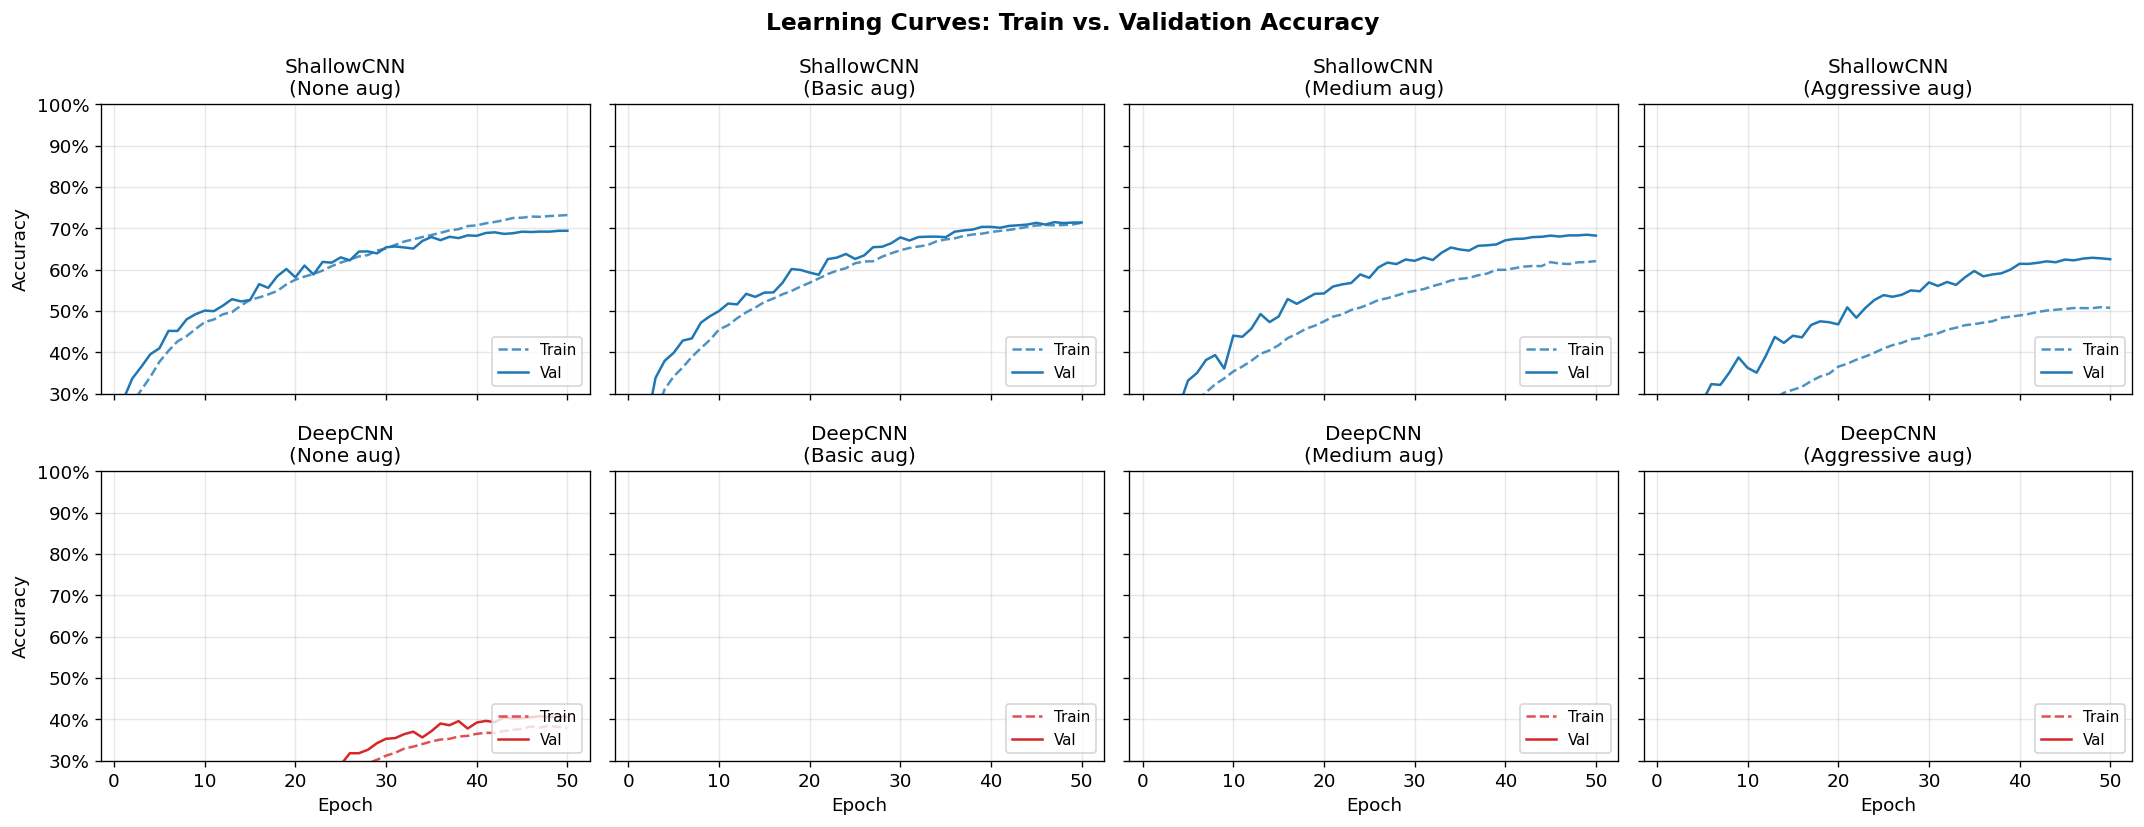

Figure 1 saved.


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Style
plt.rcParams.update({
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'legend.fontsize':  9,
    'figure.dpi':       120,
})

ARCH_COLORS = {'ShallowCNN': '#1f77b4', 'DeepCNN': '#d62728'}
AUG_LABELS  = {'none': 'None', 'basic': 'Basic',  
                'medium': 'Medium', 'aggressive': 'Aggressive'}
AUG_ORDER   = CONFIG['aug_levels']   # ['none','basic','medium','aggressive']


# ─────────────────────────────────────────────────────────────────────────────
# Plot 1: Learning curves — 2×4 grid (train & val acc per run)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharex=True, sharey=True)
fig.suptitle('Learning Curves: Train vs. Validation Accuracy', fontsize=14, fontweight='bold')

for row_i, arch in enumerate(CONFIG['architectures']):
    for col_i, aug in enumerate(AUG_ORDER):
        ax = axes[row_i][col_i]
        hist = all_histories[(arch, aug)]
        epochs     = [r['epoch']     for r in hist]
        train_accs = [r['train_acc'] for r in hist]
        val_accs   = [r['val_acc']   for r in hist]

        color = ARCH_COLORS[arch]
        ax.plot(epochs, train_accs, color=color, linewidth=1.5,
                label='Train', linestyle='--', alpha=0.8)
        ax.plot(epochs, val_accs,   color=color, linewidth=1.5,
                label='Val')
        ax.set_title(f'{arch}\n({AUG_LABELS[aug]} aug)')
        ax.set_ylim(0.3, 1.0)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)

        if row_i == 1:
            ax.set_xlabel('Epoch')
        if col_i == 0:
            ax.set_ylabel('Accuracy')

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig1_learning_curves.png', bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

C:\Users\luluz\AppData\Local\Temp\ipykernel_13972\39232031.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


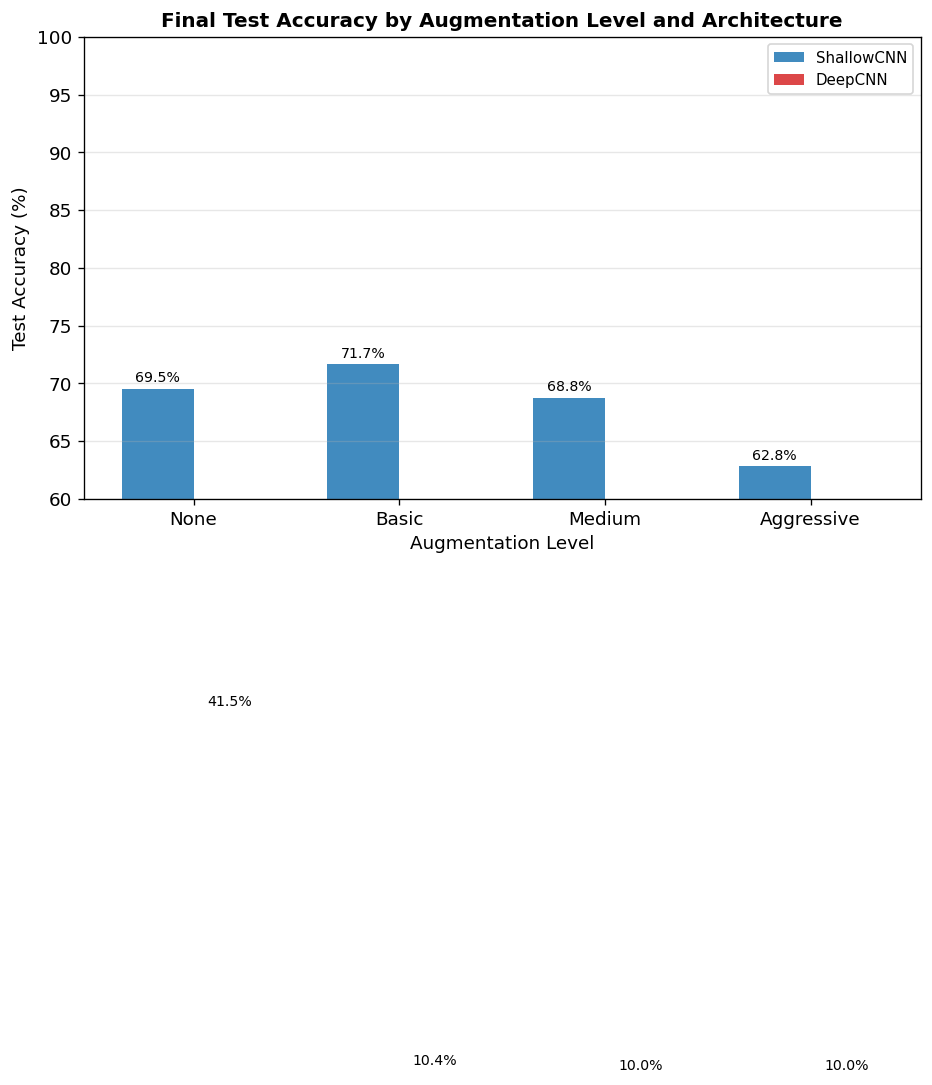

Figure 2 saved.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Plot 2: Final test accuracy bar chart (grouped by augmentation, colored by arch)
# ─────────────────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)

fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(AUG_ORDER))
width = 0.35

for offset, arch in zip([-width/2, width/2], CONFIG['architectures']):
    accs = [
        results_df.loc[
            (results_df['arch'] == arch) & (results_df['aug'] == aug),
            'test_acc'
        ].values[0]
        for aug in AUG_ORDER
    ]
    bars = ax.bar(x + offset, [a * 100 for a in accs], width,
                  label=arch, color=ARCH_COLORS[arch], alpha=0.85)
    # Value labels on bars
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'{acc*100:.1f}%',
                ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([AUG_LABELS[a] for a in AUG_ORDER])
ax.set_xlabel('Augmentation Level')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Final Test Accuracy by Augmentation Level and Architecture',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(60, 100)

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig2_bar_test_accuracy.png', bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

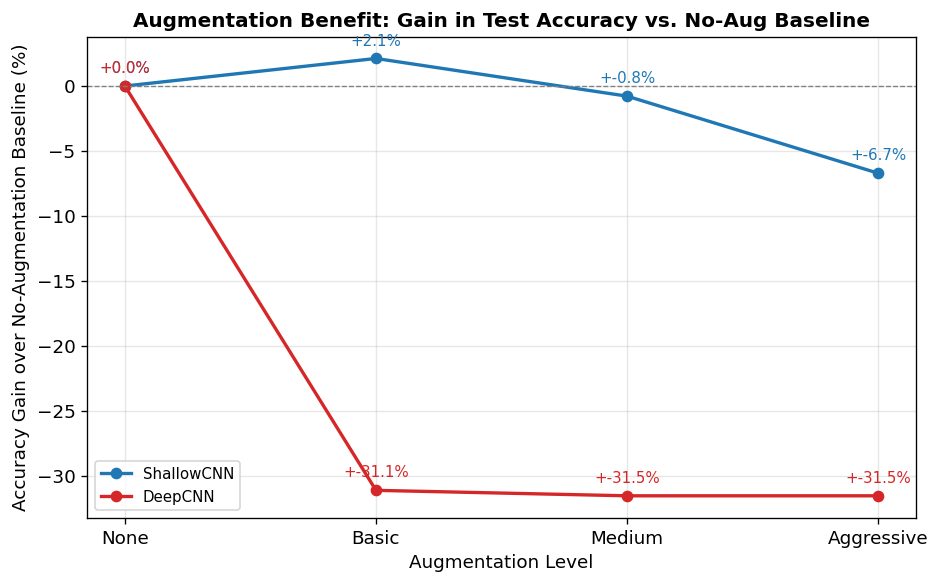

Figure 3 saved.


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Plot 3: Augmentation benefit lines (test acc vs aug level, one line per arch)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

aug_x = np.arange(len(AUG_ORDER))

for arch in CONFIG['architectures']:
    accs = [
        results_df.loc[
            (results_df['arch'] == arch) & (results_df['aug'] == aug),
            'test_acc'
        ].values[0] * 100
        for aug in AUG_ORDER
    ]
    # Gain relative to no-augmentation baseline
    gains = [a - accs[0] for a in accs]

    ax.plot(aug_x, gains, marker='o', linewidth=2,
            color=ARCH_COLORS[arch], label=arch)
    for xi, g in zip(aug_x, gains):
        ax.annotate(f'+{g:.1f}%', (xi, g),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=9, color=ARCH_COLORS[arch])

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(aug_x)
ax.set_xticklabels([AUG_LABELS[a] for a in AUG_ORDER])
ax.set_xlabel('Augmentation Level')
ax.set_ylabel('Accuracy Gain over No-Augmentation Baseline (%)')
ax.set_title('Augmentation Benefit: Gain in Test Accuracy vs. No-Aug Baseline',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig3_augmentation_benefit.png', bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

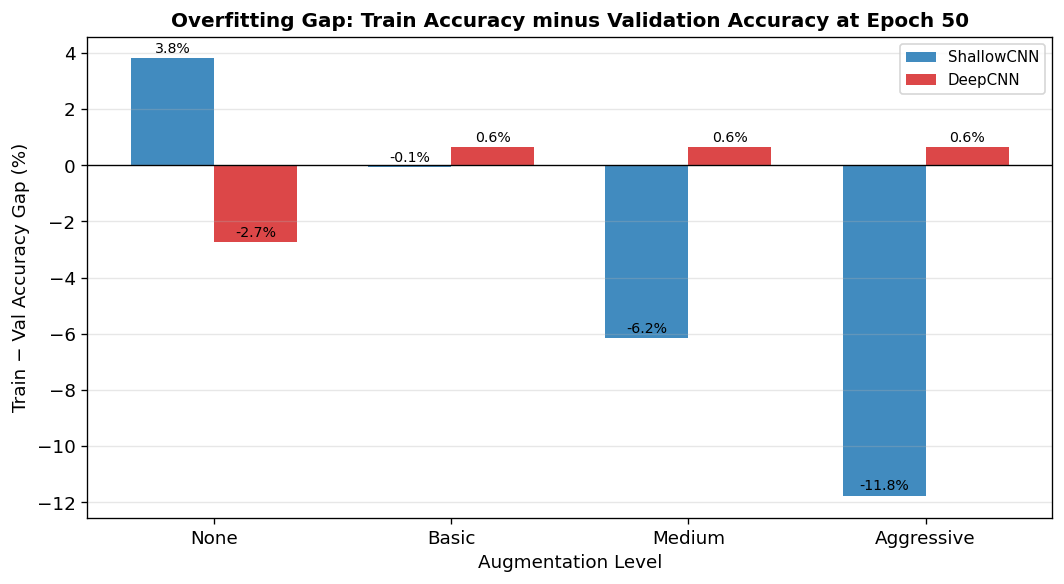

Figure 4 saved.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Plot 4: Train/Val gap bar chart (quantifies overfitting)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(AUG_ORDER))
width = 0.35

for offset, arch in zip([-width/2, width/2], CONFIG['architectures']):
    gaps = []
    for aug in AUG_ORDER:
        hist = all_histories[(arch, aug)]
        # Use final-epoch train and val acc
        last = hist[-1]
        gap  = (last['train_acc'] - last['val_acc']) * 100
        gaps.append(gap)

    bars = ax.bar(x + offset, gaps, width,
                  label=arch, color=ARCH_COLORS[arch], alpha=0.85)
    for bar, g in zip(bars, gaps):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                f'{g:.1f}%',
                ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([AUG_LABELS[a] for a in AUG_ORDER])
ax.set_xlabel('Augmentation Level')
ax.set_ylabel('Train − Val Accuracy Gap (%)')
ax.set_title('Overfitting Gap: Train Accuracy minus Validation Accuracy at Epoch 50',
             fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
fig.savefig(f'{FIGURES_DIR}/fig4_train_val_gap.png', bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

## Section 6: Summary Table

In [11]:
summary_df = pd.DataFrame(all_results)

# Friendly column names
summary_df = summary_df.rename(columns={
    'arch':           'Architecture',
    'aug':            'Augmentation',
    'test_acc':       'Test Accuracy',
    'params':         'Parameters',
    'train_time_min': 'Train Time (min)',
})

# Format
summary_df['Test Accuracy']  = summary_df['Test Accuracy'].map(lambda x: f'{x*100:.2f}%')
summary_df['Parameters']     = summary_df['Parameters'].map(lambda x: f'{x:,}')
summary_df['Augmentation']   = summary_df['Augmentation'].map(AUG_LABELS)

print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv(f'{RESULTS_DIR}/summary.csv', index=False)
print(f'\nSummary saved to {RESULTS_DIR}/summary.csv')

Architecture Augmentation Test Accuracy Parameters  Train Time (min)
  ShallowCNN         None        69.55%    620,810             19.30
  ShallowCNN        Basic        71.67%    620,810             19.80
  ShallowCNN       Medium        68.77%    620,810             50.03
  ShallowCNN   Aggressive        62.84%    620,810             57.81
     DeepCNN         None        41.53%  3,249,994             19.71
     DeepCNN        Basic        10.42%  3,249,994            470.18
     DeepCNN       Medium        10.00%  3,249,994             53.36
     DeepCNN   Aggressive        10.00%  3,249,994             61.49

Summary saved to C:\Users\luluz/cogs181_results/summary.csv


---
## End of Notebook

All results saved to:
- `run_logs.csv` — per-epoch metrics for all 8 runs
- `summary.csv`  — final test accuracy summary
- `figures/fig1_learning_curves.png`
- `figures/fig2_bar_test_accuracy.png`
- `figures/fig3_augmentation_benefit.png`
- `figures/fig4_train_val_gap.png`